# 06 — Train Conditional DCGAN (Phase 7)

**Goal:** Train a class-conditioned DCGAN on ISIC 2018 Task 3 so Phase 8 can sample synthetic minority-class images. This is the *sharp* counterpart to the Phase 6 CVAE — VAEs are stable but blurry, GANs are unstable but sharp.

**Key design choices** (documented in `src/models/cgan.py`):
- DCGAN (Radford et al. 2016): ConvTranspose+BN+LeakyReLU in G, Conv+BN+LeakyReLU in D, Tanh at G output, Sigmoid at D output, weights init from N(0, 0.02).
- **Conditioning**: one-hot label concatenated to noise `z` (G); spatially broadcast to 7 extra channels and concatenated to the input image (D).
- Output range **[-1, 1]** because of Tanh — so the training transform normalises with mean=0.5, std=0.5 (NOT ImageNet, NOT [0,1] like the CVAE).
- Adam, **lr=2e-4, betas=(0.5, 0.999)** — DCGAN-paper defaults.
- **No EarlyStopping.** GANs don't have a meaningful val loss — the losses bounce around as G and D play each other. We train for a fixed number of epochs, snapshot every few epochs, and pick the best by visual inspection and (in Phase 9) FID.

**Outputs** (matching the Phase 5/6 convention):
- `results/checkpoints/cgan_G_final.pt`, `cgan_D_final.pt`
- `results/checkpoints/cgan_G_epochXX.pt` (periodic snapshots, so we can pick the best one later)
- `results/logs/cgan_log.csv`
- `results/plots/cgan_losses.png`
- `results/plots/cgan_samples_epochXX.png` (fixed-noise sample grid per snapshot)
- `results/plots/cgan_samples_per_class_final.png`

## 1. Setup, paths, seed

In [2]:
import sys
from pathlib import Path
import csv
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import ISICDataset, CLASS_NAMES          # noqa: E402
from src.models.cgan import (                              # noqa: E402
    Generator, Discriminator,
    init_dcgan_weights, sample_images,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU : {torch.cuda.get_device_name(0)}')

RESULTS = PROJECT_ROOT / 'results'
(RESULTS / 'checkpoints').mkdir(parents=True, exist_ok=True)
(RESULTS / 'logs').mkdir(parents=True, exist_ok=True)
(RESULTS / 'plots').mkdir(parents=True, exist_ok=True)

LOG_PATH = RESULTS / 'logs' / 'cgan_log.csv'
print(f'Log -> {LOG_PATH}')

Device: cuda
  GPU : NVIDIA A100-SXM4-80GB
Log -> /home/mayarn/skin-cancer/skin-lesion/results/logs/cgan_log.csv


## 2. Hyperparameters

We use fewer epochs than the CVAE (50 vs. 60) because GANs see each batch twice per step (once for D, once for G), and training instability tends to get worse the longer you go. We use the DCGAN-paper defaults for the rest: lr=2e-4, Adam betas=(0.5, 0.999), latent_dim=100. We also save a snapshot of G and D every 5 epochs so we can pick the best generator by inspection later — for GANs, the last epoch is not necessarily the best epoch.

In [3]:
IMG_SIZE       = 224
BATCH_SIZE     = 32       # drop to 16 if OOM (GANs are memory-hungry)
LATENT_DIM     = 100      # DCGAN paper default
N_CLASSES      = len(CLASS_NAMES)   # 7
EPOCHS         = 50
LR             = 2e-4     # DCGAN paper default
BETAS          = (0.5, 0.999)   # DCGAN paper default
SNAPSHOT_EVERY = 5        # save G/D + sample grid every N epochs
NUM_WORKERS    = 4

print(f'image size     : {IMG_SIZE}')
print(f'batch size     : {BATCH_SIZE}')
print(f'latent dim     : {LATENT_DIM}')
print(f'epochs         : {EPOCHS}')
print(f'lr             : {LR}    betas={BETAS}')
print(f'snapshot every : {SNAPSHOT_EVERY} epochs')

image size     : 224
batch size     : 32
latent dim     : 100
epochs         : 50
lr             : 0.0002    betas=(0.5, 0.999)
snapshot every : 5 epochs


## 3. Data — Tanh-friendly transforms ([-1, 1] range)

Same `ISICDataset` and same `splits.csv` as Phases 5 and 6, but the transform normalises to **[-1, 1]** (mean=0.5, std=0.5 per channel) to match the Generator's Tanh output.

We only use the `train` split — GAN training has no validation: there's nothing to validate against, since the loss is adversarial.

In [4]:
# [0,1]  --(mean=0.5, std=0.5)-->  [-1, 1]
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),                             # [0, 1]
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),  # [-1, 1]
])

splits_csv = PROJECT_ROOT / 'data' / 'processed' / 'splits.csv'
images_dir = PROJECT_ROOT / 'data' / 'raw' / 'ISIC2018_Task3_Training_Input'

train_ds = ISICDataset(splits_csv, images_dir, split='train', transform=train_tf)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

print(f'train batches : {len(train_loader)}   ({len(train_ds)} images)')

x, y = next(iter(train_loader))
print(f'\nbatch x : {tuple(x.shape)}   dtype={x.dtype}   '
      f'min={x.min():.3f}  max={x.max():.3f}   (expected ~[-1, 1])')
print(f'batch y : {tuple(y.shape)}   unique={sorted(y.unique().tolist())}')

train batches : 219   (7009 images)



batch x : (32, 3, 224, 224)   dtype=torch.float32   min=-1.000  max=1.000   (expected ~[-1, 1])
batch y : (32,)   unique=[0, 1, 2, 3, 4, 6]


## 4. Model, optimizers, loss

In [ ]:
G = Generator(latent_dim=LATENT_DIM, n_classes=N_CLASSES).to(DEVICE)
D = Discriminator(n_classes=N_CLASSES).to(DEVICE)
G.apply(init_dcgan_weights)
D.apply(init_dcgan_weights)

opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=BETAS)
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=BETAS)

criterion = nn.BCELoss()  

print(f'Generator     params: {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator params: {sum(p.numel() for p in D.parameters()):,}')

# A fixed noise+label grid we'll use for monitoring -- 4 samples per class,
# regenerated at every snapshot epoch from the SAME z and y so we can see
# how that fixed point in latent space evolves over training.
MONITOR_N = 4
fixed_z = torch.randn(MONITOR_N * N_CLASSES, LATENT_DIM, device=DEVICE)
fixed_y = torch.arange(N_CLASSES, device=DEVICE).repeat_interleave(MONITOR_N)
print(f'\nfixed monitor batch: {fixed_z.shape[0]} samples '
      f'({MONITOR_N} per class)')

Generator     params: 7,884,224
Discriminator params: 6,968,065

fixed monitor batch: 28 samples (4 per class)


## 5. Snapshot helper — save G/D and a sample grid

In [6]:
def save_snapshot(epoch: int) -> None:
    """Save G, D, and a (n_classes x MONITOR_N) grid of fixed-noise samples."""
    g_path = RESULTS / 'checkpoints' / f'cgan_G_epoch{epoch:02d}.pt'
    d_path = RESULTS / 'checkpoints' / f'cgan_D_epoch{epoch:02d}.pt'
    torch.save({
        'epoch': epoch, 'state_dict': G.state_dict(),
        'latent_dim': LATENT_DIM, 'n_classes': N_CLASSES,
    }, g_path)
    torch.save({
        'epoch': epoch, 'state_dict': D.state_dict(),
        'n_classes': N_CLASSES,
    }, d_path)

    G.eval()
    with torch.no_grad():
        imgs = G(fixed_z, fixed_y)                # (n_classes*MONITOR_N, 3, 224, 224) in [-1,1]
        imgs = ((imgs + 1.0) / 2.0).clamp(0.0, 1.0)
    G.train()

    imgs_np = imgs.cpu().permute(0, 2, 3, 1).numpy()
    fig, axes = plt.subplots(N_CLASSES, MONITOR_N,
                             figsize=(1.8 * MONITOR_N, 1.8 * N_CLASSES))
    for c in range(N_CLASSES):
        for j in range(MONITOR_N):
            ax = axes[c, j]
            ax.imshow(imgs_np[c * MONITOR_N + j])
            ax.axis('off')
            if j == 0:
                ax.set_ylabel(CLASS_NAMES[c], fontsize=10, rotation=0,
                              labelpad=28, va='center')
    plt.suptitle(f'cGAN samples — epoch {epoch} (fixed z)', y=1.01)
    plt.tight_layout()
    out = RESULTS / 'plots' / f'cgan_samples_epoch{epoch:02d}.png'
    plt.savefig(out, dpi=110, bbox_inches='tight')
    plt.close(fig)
    print(f'  -> saved snapshot: {g_path.name}, {out.name}')

## 6. Training loop

Per batch:

1. **Train D** on a real batch (target=1) and a fake batch (target=0). Backprop, step D.
2. **Train G** by generating a new fake batch and computing BCE against target=1 — we want D to think these fakes are real. Backprop through D, but only step G.

Both steps use the class label to condition. When training D on a fake batch, the label given to D is the same one G was conditioned on, so D learns class consistency in addition to realism.

We track four numbers per epoch: D_loss, G_loss, D(x) (the probability D assigns to real samples), and D(G(z)) (the probability D assigns to G's fakes, measured both before and after the G update). A healthy run keeps D(x) and D(G(z)) close together — that means neither side is dominating.

In [7]:
with open(LOG_PATH, 'w', newline='') as f:
    csv.writer(f).writerow(['epoch', 'D_loss', 'G_loss', 'D_x', 'D_G_z1', 'D_G_z2'])

history = {'epoch': [], 'D_loss': [], 'G_loss': [],
           'D_x': [], 'D_G_z1': [], 'D_G_z2': []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    G.train(); D.train()

    run = {'D_loss': 0.0, 'G_loss': 0.0, 'D_x': 0.0, 'D_G_z1': 0.0, 'D_G_z2': 0.0}
    n_batches = 0

    for real, y in train_loader:
        bsz = real.size(0)
        real = real.to(DEVICE, non_blocking=True)
        y    = y.to(DEVICE, non_blocking=True)

        ones  = torch.ones (bsz, 1, device=DEVICE)
        zeros = torch.zeros(bsz, 1, device=DEVICE)

        # ============================================================
        # 1)  Train D : maximise log D(x, y) + log(1 - D(G(z, y), y))
        # ============================================================
        opt_D.zero_grad()

        # real batch
        d_real = D(real, y)
        loss_d_real = criterion(d_real, ones)

        # fake batch  (detach so G isn't updated here)
        z = torch.randn(bsz, LATENT_DIM, device=DEVICE)
        fake = G(z, y)
        d_fake = D(fake.detach(), y)
        loss_d_fake = criterion(d_fake, zeros)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        opt_D.step()

        # ============================================================
        # 2)  Train G : maximise log D(G(z, y), y)  -- target = 1
        # ============================================================
        opt_G.zero_grad()
        # Re-run D on the SAME fake batch (no detach this time)
        d_fake_for_g = D(fake, y)
        loss_g = criterion(d_fake_for_g, ones)
        loss_g.backward()
        opt_G.step()

        # bookkeeping
        run['D_loss'] += loss_d.item()
        run['G_loss'] += loss_g.item()
        run['D_x']    += d_real.mean().item()
        run['D_G_z1'] += d_fake.mean().item()           # before G step
        run['D_G_z2'] += d_fake_for_g.mean().item()     # after  G step
        n_batches += 1

    # per-epoch averages
    for k in run:
        run[k] /= n_batches

    history['epoch'].append(epoch)
    for k, v in run.items():
        history[k].append(v)

    with open(LOG_PATH, 'a', newline='') as f:
        csv.writer(f).writerow([epoch, run['D_loss'], run['G_loss'],
                                run['D_x'], run['D_G_z1'], run['D_G_z2']])

    dt = time.time() - t0
    print(f'Epoch {epoch:3d}/{EPOCHS}  '
          f"D_loss={run['D_loss']:.3f}  G_loss={run['G_loss']:.3f}  |  "
          f"D(x)={run['D_x']:.3f}  D(G(z))={run['D_G_z1']:.3f}->{run['D_G_z2']:.3f}  "
          f"({dt:.1f}s)")

    if epoch % SNAPSHOT_EVERY == 0 or epoch == EPOCHS:
        save_snapshot(epoch)

# Always save a final, named checkpoint -- this is what Phase 8 loads
torch.save({
    'epoch': EPOCHS, 'state_dict': G.state_dict(),
    'latent_dim': LATENT_DIM, 'n_classes': N_CLASSES,
}, RESULTS / 'checkpoints' / 'cgan_G_final.pt')
torch.save({
    'epoch': EPOCHS, 'state_dict': D.state_dict(),
    'n_classes': N_CLASSES,
}, RESULTS / 'checkpoints' / 'cgan_D_final.pt')
print('\nTraining done. Saved cgan_G_final.pt and cgan_D_final.pt')

Epoch   1/50  D_loss=0.548  G_loss=3.681  |  D(x)=0.815  D(G(z))=0.188->0.077  (17.2s)
Epoch   2/50  D_loss=0.924  G_loss=2.235  |  D(x)=0.695  D(G(z))=0.306->0.183  (16.6s)
Epoch   3/50  D_loss=1.110  G_loss=1.768  |  D(x)=0.622  D(G(z))=0.377->0.230  (16.4s)
Epoch   4/50  D_loss=1.239  G_loss=1.416  |  D(x)=0.577  D(G(z))=0.423->0.285  (16.6s)
Epoch   5/50  D_loss=1.301  G_loss=1.194  |  D(x)=0.550  D(G(z))=0.448->0.331  (16.5s)
  -> saved snapshot: cgan_G_epoch05.pt, cgan_samples_epoch05.png
Epoch   6/50  D_loss=1.305  G_loss=1.082  |  D(x)=0.541  D(G(z))=0.457->0.359  (16.4s)
Epoch   7/50  D_loss=1.322  G_loss=1.066  |  D(x)=0.536  D(G(z))=0.464->0.363  (16.7s)
Epoch   8/50  D_loss=1.324  G_loss=1.018  |  D(x)=0.533  D(G(z))=0.465->0.378  (16.8s)
Epoch   9/50  D_loss=1.325  G_loss=1.030  |  D(x)=0.534  D(G(z))=0.467->0.373  (16.7s)
Epoch  10/50  D_loss=1.343  G_loss=0.993  |  D(x)=0.528  D(G(z))=0.472->0.385  (16.8s)
  -> saved snapshot: cgan_G_epoch10.pt, cgan_samples_epoch10.png


## 7. Training curves

These curves look very different from the VAE's: there is no converging validation loss because GAN training has no validation set. What matters is the relationship between the two losses. From around epoch 5 to epoch 37, the two losses sit at a steady equilibrium (D_loss ≈ 1.37, G_loss ≈ 0.9) and the discriminator's confidences hover near 0.5 — both signs of a balanced game. After epoch 37, D_loss drops sharply while G_loss climbs, which means the discriminator has started to overpower the generator. We will not use the final-epoch generator for downstream sampling; we pick an earlier snapshot instead (see the wrap-up below).

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/cgan_losses.png


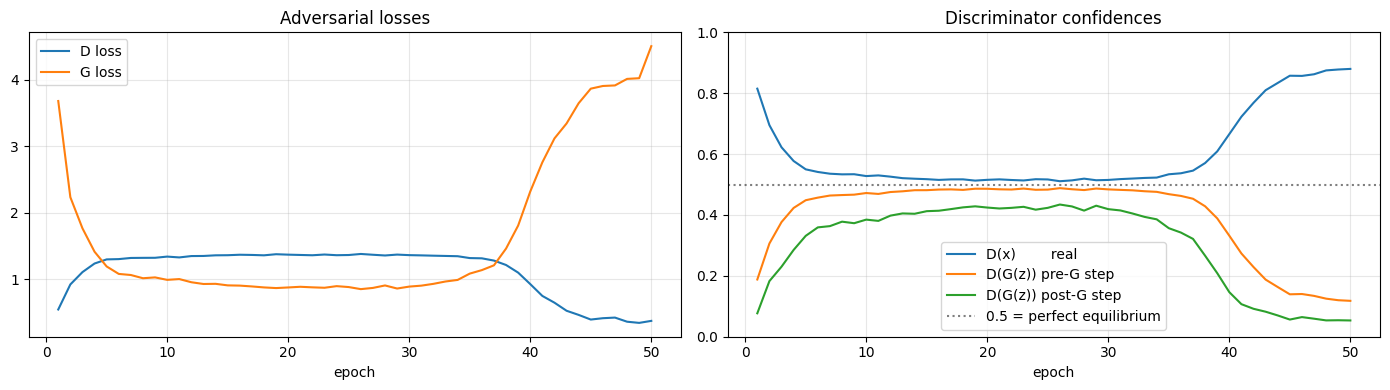

In [8]:
log = pd.read_csv(LOG_PATH)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(log['epoch'], log['D_loss'], label='D loss')
axes[0].plot(log['epoch'], log['G_loss'], label='G loss')
axes[0].set_title('Adversarial losses')
axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(log['epoch'], log['D_x'],    label='D(x)        real')
axes[1].plot(log['epoch'], log['D_G_z1'], label='D(G(z)) pre-G step')
axes[1].plot(log['epoch'], log['D_G_z2'], label='D(G(z)) post-G step')
axes[1].axhline(0.5, color='k', linestyle=':', alpha=0.5, label='0.5 = perfect equilibrium')
axes[1].set_ylim(0, 1)
axes[1].set_title('Discriminator confidences')
axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
out = RESULTS / 'plots' / 'cgan_losses.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## 8. Final per-class sample grid

Six samples per class drawn from the final generator (epoch 50). Note: this grid is mainly for completeness — we showed above that the final generator has degraded, so for the actual downstream use in Phase 8 we will load an earlier snapshot (see the wrap-up). Each row of this grid should still show some variation; if a row is identical across all six samples, that class has mode-collapsed.

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/cgan_samples_per_class_final.png


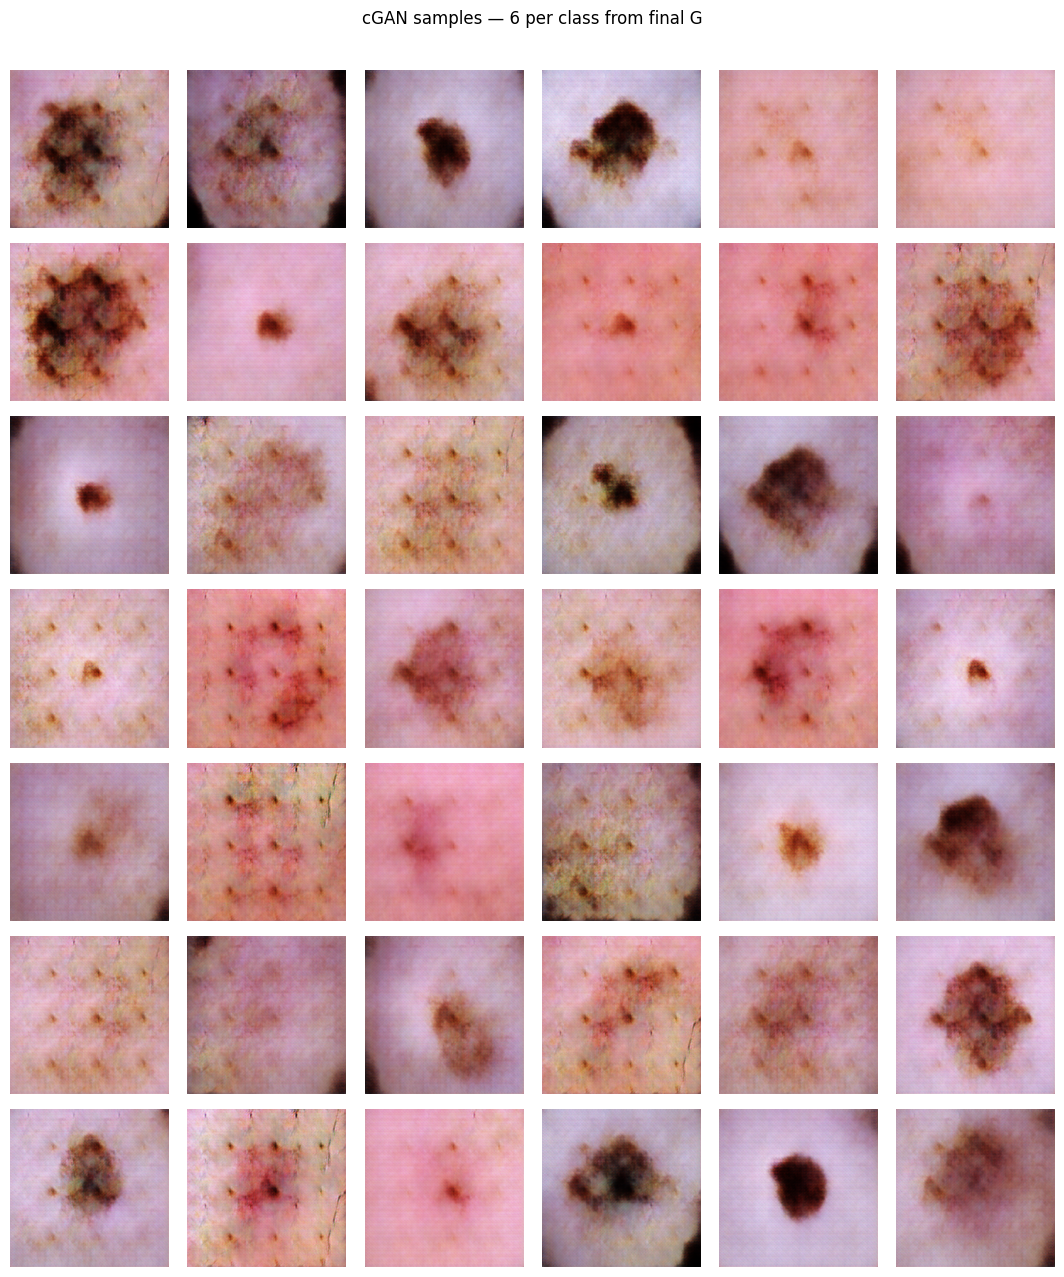

In [9]:
N_PER_CLASS = 6
fig, axes = plt.subplots(N_CLASSES, N_PER_CLASS,
                         figsize=(1.8 * N_PER_CLASS, 1.8 * N_CLASSES))

for c in range(N_CLASSES):
    samples = sample_images(G, class_idx=c, n=N_PER_CLASS, device=DEVICE)
    samples = samples.cpu().permute(0, 2, 3, 1).numpy()
    for j in range(N_PER_CLASS):
        ax = axes[c, j]
        ax.imshow(samples[j])
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(CLASS_NAMES[c], fontsize=11, rotation=0,
                          labelpad=30, va='center')

plt.suptitle('cGAN samples — 6 per class from final G', y=1.01)
plt.tight_layout()
out = RESULTS / 'plots' / 'cgan_samples_per_class_final.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## 9. cGAN trained — picking the best generator

The cGAN trained for the full 50 epochs in about 14 minutes. The training trajectory has two clear phases:

- **Epochs 5–37:** stable Nash equilibrium. D_loss stayed near 1.37, G_loss near 0.9, and D's confidences on real and fake samples hovered close to each other (D(x) ≈ 0.52, D(G(z)) ≈ 0.42). The fixed-noise snapshots in this range show diverse, lesion-shaped samples with good colour variation across classes.
- **Epochs 38–50:** the discriminator started winning. D_loss dropped to 0.38, G_loss climbed to 4.5, and the snapshots developed visible texture artifacts (repeating dot patterns in the background) and lost some of the colour diversity seen earlier.

This kind of late-stage discriminator dominance is a well-known GAN failure mode and is exactly why we saved snapshots every 5 epochs rather than only the final weights. Going through the snapshots side by side, the cleanest generator is the one from **epoch 30** — sharp lesion shapes, varied positions and colours, no visible texture artifacts. We will use `cgan_G_epoch30.pt` (not `cgan_G_final.pt`) as the cGAN checkpoint for synthetic-image generation in Phase 8.

We are not retraining. The first 35 epochs are textbook behaviour and re-running with the same hyperparameters would almost certainly reproduce the same trajectory, including the late-stage collapse. Picking an earlier checkpoint is the standard fix.

Outputs saved under `results/`:

- `checkpoints/cgan_G_final.pt`, `cgan_D_final.pt`
- `checkpoints/cgan_G_epoch05.pt` through `cgan_G_epoch50.pt` (snapshots every 5 epochs)
- `logs/cgan_log.csv`
- `plots/cgan_losses.png`
- `plots/cgan_samples_epochXX.png` (one per snapshot)
- `plots/cgan_samples_per_class_final.png`